# Feature Engineering and Feature Selection

Building out a proper feature set for modeling `Cause Category` (the models
themselves are in the next notebook). This is where I create new columns from
the raw data, then figure out which of them are actually worth keeping.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set(style="whitegrid")
plt.style.use('ggplot')

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

In [2]:
pipe = pd.read_csv('pipeline-accidents.csv')
pipe.shape

(2795, 48)

## Feature creation

**Time features** - pulling month, day of week and hour out of the accident timestamp. Pipeline work and inspection schedules aren't random across the week/year, so this seemed worth trying.

In [3]:
accident_dt = pd.to_datetime(pipe['Accident Date/Time'])

pipe['accident_month'] = accident_dt.dt.month
pipe['accident_dow'] = accident_dt.dt.dayofweek       # 0 = Monday
pipe['accident_hour'] = accident_dt.dt.hour

pipe[['Accident Date/Time', 'accident_month', 'accident_dow', 'accident_hour']].head()

,Accident Date/Time,accident_month,accident_dow,accident_hour
0,1/1/2010 7:15 AM,1,4,7
1,1/4/2010 8:30 AM,1,0,8
2,1/5/2010 10:30 AM,1,1,10
3,1/6/2010 7:30 PM,1,2,19
4,1/7/2010 1:00 PM,1,3,13


**Shutdown duration** - how long the pipeline was down for, in hours, when we have both a shutdown and restart timestamp. Most rows don't have a shutdown at all, so those become 0 and get their own flag.

In [4]:
shutdown_dt = pd.to_datetime(pipe['Shutdown Date/Time'], errors = 'coerce')
restart_dt = pd.to_datetime(pipe['Restart Date/Time'], errors = 'coerce')

pipe['shutdown_duration_hrs'] = (restart_dt - shutdown_dt).dt.total_seconds() / 3600
pipe['shutdown_duration_hrs'] = pipe['shutdown_duration_hrs'].fillna(0)
pipe['had_shutdown'] = (pipe['Pipeline Shutdown'] == 'YES').astype(int)

pipe[['Pipeline Shutdown', 'had_shutdown', 'shutdown_duration_hrs']].head()

,Pipeline Shutdown,had_shutdown,shutdown_duration_hrs
0,NO,0,0.0
1,NaN,0,0.0
2,NaN,0,0.0
3,NaN,0,0.0
4,NO,0,0.0


**Simple severity flags** - was anyone evacuated, injured, or killed. These are rare events (most incidents have none of this), so they're mostly useful as extra signal rather than a feature that carries the whole model.

In [5]:
pipe['has_evacuation'] = (pipe['Public Evacuations'].fillna(0) > 0).astype(int)
pipe['has_injury'] = (pipe['All Injuries'].fillna(0) > 0).astype(int)
pipe['has_fatality'] = (pipe['All Fatalities'].fillna(0) > 0).astype(int)

pipe[['has_evacuation', 'has_injury', 'has_fatality']].sum()

has_evacuation    53
has_injury        12
has_fatality       8
dtype: int64

**Log transforms** - release volumes and costs are heavily right skewed (saw this in the EDA notebook), so raw values would let a handful of huge incidents dominate anything tree-based or linear.

In [6]:
pipe['log_net_loss'] = np.log1p(pipe['Net Loss (Barrels)'])
pipe['log_unintentional_release'] = np.log1p(pipe['Unintentional Release (Barrels)'])
pipe['log_all_costs'] = np.log1p(pipe['All Costs'])

**Ratio features** - how much of what leaked out actually got recovered, and roughly how expensive the cleanup was per barrel lost. Both should say something about severity that the raw volumes alone don't.

In [7]:
pipe['recovery_rate'] = (pipe['Liquid Recovery (Barrels)'].fillna(0) / (pipe['Unintentional Release (Barrels)'] + 1)).clip(0, 1)
pipe['cost_per_barrel'] = np.log1p(pipe['All Costs'] / (pipe['Net Loss (Barrels)'] + 1))

pipe[['recovery_rate', 'cost_per_barrel']].describe()

,recovery_rate,cost_per_barrel
count,2795.000000,2795.000000
mean,0.414053,9.067374
std,0.360626,2.593490
min,0.000000,0.000000
25%,0.000000,7.717055
50%,0.341880,9.222862
75%,0.761747,10.682402
max,0.999867,17.673997


**Region from state** - 46 individual states is a lot of sparse categories for a model to learn from, so grouping them into the standard 4 Census regions (plus an 'Other/Territory' bucket for Puerto Rico) gives a coarser, more learnable location signal.

In [8]:
region_map = {
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast', 'NJ': 'Northeast',
    'NY': 'Northeast', 'PA': 'Northeast', 'RI': 'Northeast', 'VT': 'Northeast',
    'IL': 'Midwest', 'IN': 'Midwest', 'IA': 'Midwest', 'KS': 'Midwest', 'MI': 'Midwest', 'MN': 'Midwest',
    'MO': 'Midwest', 'NE': 'Midwest', 'ND': 'Midwest', 'OH': 'Midwest', 'SD': 'Midwest', 'WI': 'Midwest',
    'AL': 'South', 'AR': 'South', 'DE': 'South', 'FL': 'South', 'GA': 'South', 'KY': 'South', 'LA': 'South',
    'MD': 'South', 'MS': 'South', 'NC': 'South', 'OK': 'South', 'SC': 'South', 'TN': 'South', 'TX': 'South',
    'VA': 'South', 'WV': 'South', 'DC': 'South',
    'AK': 'West', 'AZ': 'West', 'CA': 'West', 'CO': 'West', 'HI': 'West', 'ID': 'West', 'MT': 'West',
    'NV': 'West', 'NM': 'West', 'OR': 'West', 'UT': 'West', 'WA': 'West', 'WY': 'West',
}

pipe['region'] = pipe['Accident State'].map(region_map).fillna('Other/Territory')
pipe['region'].value_counts()

region
South              1581
Midwest             651
West                401
Northeast           149
Other/Territory      13
Name: count, dtype: int64

That's the feature set - quick look at everything new before moving on to selection.

In [9]:
new_cols = ['accident_month', 'accident_dow', 'accident_hour', 'shutdown_duration_hrs', 'had_shutdown',
            'has_evacuation', 'has_injury', 'has_fatality', 'log_net_loss', 'log_unintentional_release',
            'log_all_costs', 'recovery_rate', 'cost_per_barrel', 'region']

pipe[new_cols].head()

,accident_month,accident_dow,accident_hour,shutdown_duration_hrs,had_shutdown,has_evacuation,has_injury,has_fatality,log_net_loss,log_unintentional_release,log_all_costs,recovery_rate,cost_per_barrel,region
0,1,4,7,0.0,0,0,0,0,3.091042,3.091042,7.395108,0.000000,4.316882,Midwest
1,1,0,8,0.0,0,0,0,0,0.000000,0.113329,8.296297,0.107143,8.296297,Northeast
2,1,1,10,0.0,0,0,0,0,1.098612,1.098612,5.303305,0.000000,4.214594,South
3,1,2,19,0.0,0,0,0,0,0.000000,0.392042,9.353661,0.324324,9.353661,Midwest
4,1,3,13,0.0,0,0,0,0,1.098612,6.552508,10.297251,0.995720,9.198706,South


## Feature selection

Target is `Cause Category`. Checking the created numeric features plus `Pipeline Type`, `Liquid Type` and `region` as categoricals.

In [10]:
numeric_features = ['accident_month', 'accident_dow', 'accident_hour', 'shutdown_duration_hrs',
                     'has_evacuation', 'has_injury', 'has_fatality', 'log_net_loss',
                     'log_unintentional_release', 'log_all_costs', 'recovery_rate', 'cost_per_barrel']
categorical_features = ['Pipeline Type', 'Liquid Type', 'region']

X_num = pipe[numeric_features].copy()

le_target = LabelEncoder()
y = le_target.fit_transform(pipe['Cause Category'])

**Correlation filter** - dropping anything that's basically a duplicate of another numeric feature (I used 0.85 as the redundancy cutoff).

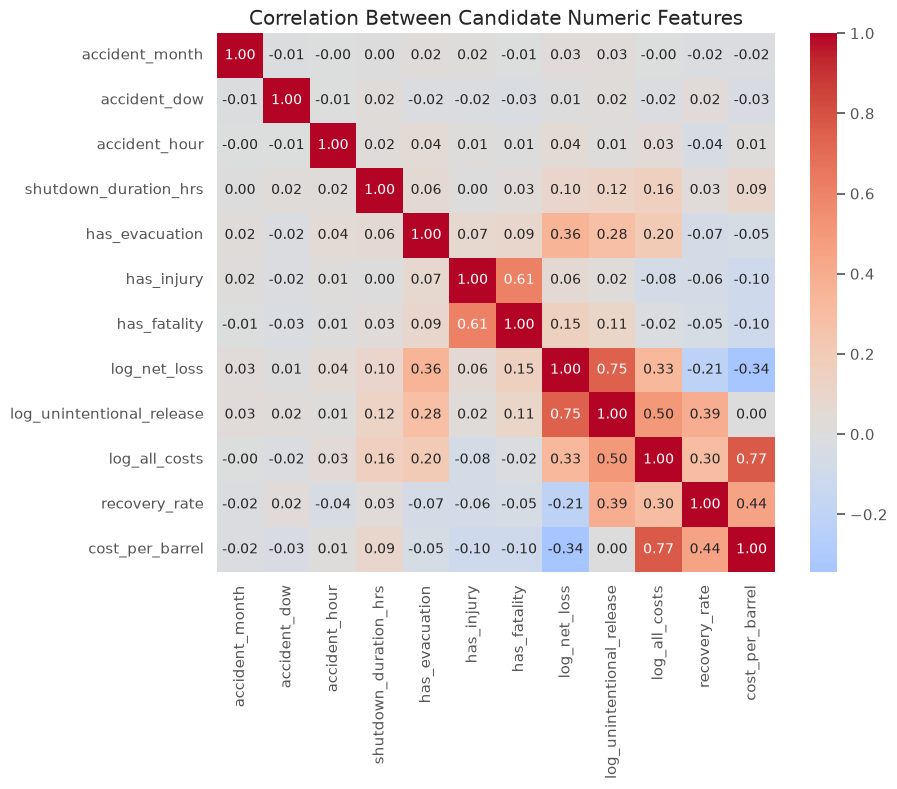

In [11]:
num_corr = X_num.corr()

plt.figure(figsize = (9, 7))
sns.heatmap(num_corr, annot = True, fmt = '.2f', cmap = 'coolwarm', center = 0)
plt.title('Correlation Between Candidate Numeric Features')
plt.show()

In [12]:
high_corr_pairs = []
for i in range(len(num_corr.columns)):
    for j in range(i + 1, len(num_corr.columns)):
        c = num_corr.iloc[i, j]
        if abs(c) > 0.85:
            high_corr_pairs.append((num_corr.columns[i], num_corr.columns[j], round(c, 2)))

high_corr_pairs

[]

`log_net_loss` and `log_unintentional_release` are correlated (0.75) but not over the 0.85 cutoff, so nothing gets dropped here - the log transform already pulled them apart more than the raw barrel counts were (those sit at 0.92).

**Mutual information** - a more general dependence measure than correlation, works fine against a multiclass target.

In [13]:
mi_scores = mutual_info_classif(X_num, y, random_state = 42)
mi_series = pd.Series(mi_scores, index = numeric_features).sort_values(ascending = False)
mi_series

log_all_costs                0.079104
log_unintentional_release    0.071511
cost_per_barrel              0.055165
shutdown_duration_hrs        0.042684
log_net_loss                 0.038990
has_fatality                 0.019940
recovery_rate                0.019202
accident_hour                0.018693
accident_month               0.003015
has_injury                   0.002370
accident_dow                 0.000000
has_evacuation               0.000000
dtype: float64

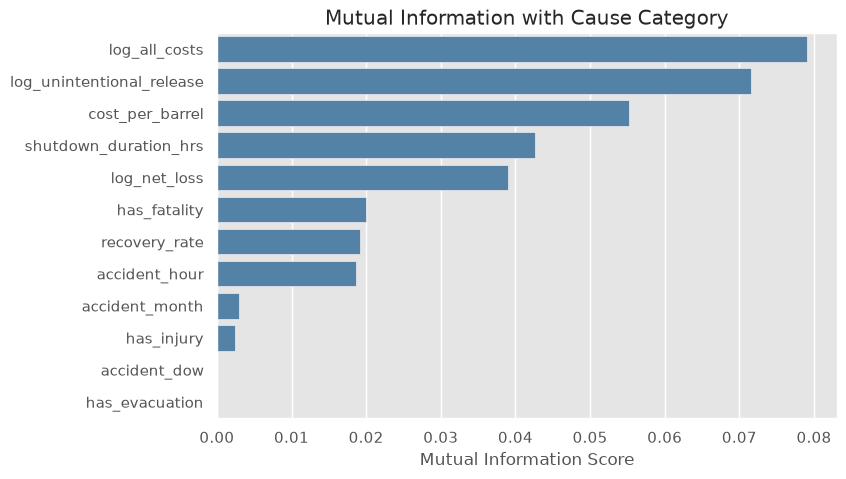

In [14]:
plt.figure(figsize = (8, 5))
sns.barplot(x = mi_series.values, y = mi_series.index, color = 'steelblue')
plt.title('Mutual Information with Cause Category')
plt.xlabel('Mutual Information Score')
plt.ylabel('')
plt.show()

**Chi-square** - for the categorical side, one-hot encode and score each dummy column against the target.

In [15]:
X_cat = pd.get_dummies(pipe[categorical_features])
chi2_scores, chi2_p = chi2(X_cat, y)

chi2_results = pd.DataFrame({'feature': X_cat.columns, 'chi2': chi2_scores, 'p_value': chi2_p})
chi2_results.sort_values('chi2', ascending = False).head(15)

,feature,chi2,p_value
3,Pipeline Type_UNDERGROUND,451.236741,2.659227e-94
0,Pipeline Type_ABOVEGROUND,257.418703,1.064578e-52
6,Liquid Type_CRUDE OIL,69.235029,5.867377e-13
1,Pipeline Type_TANK,68.291426,9.157384e-13
7,Liquid Type_HVL OR OTHER FLAMMABLE OR TOXIC FL...,57.196455,1.667034e-10
9,region_Midwest,48.745047,8.385307e-09
8,Liquid Type_REFINED AND/OR PETROLEUM PRODUCT (...,30.018037,3.899930e-05
12,region_South,17.455539,7.747110e-03
11,region_Other/Territory,15.955141,1.399678e-02
4,Liquid Type_BIOFUEL / ALTERNATIVE FUEL(INCLUDI...,13.540310,3.521459e-02


**Model-based importance** - fitting a quick Random Forest on everything and reading off `feature_importances_` as a third, independent vote.

In [16]:
X_all = pd.concat([X_num.reset_index(drop = True), X_cat.reset_index(drop = True)], axis = 1)

rf_selector = RandomForestClassifier(n_estimators = 300, random_state = 42,
                                       class_weight = 'balanced', n_jobs = -1)
rf_selector.fit(X_all, y)

importances = pd.Series(rf_selector.feature_importances_, index = X_all.columns).sort_values(ascending = False)
importances.head(15)

log_all_costs                                                     0.120161
cost_per_barrel                                                   0.118320
log_unintentional_release                                         0.111918
accident_hour                                                     0.090730
recovery_rate                                                     0.087703
accident_month                                                    0.082379
shutdown_duration_hrs                                             0.078017
log_net_loss                                                      0.066423
accident_dow                                                      0.062531
Pipeline Type_UNDERGROUND                                         0.032737
Pipeline Type_ABOVEGROUND                                         0.022293
Liquid Type_CRUDE OIL                                             0.019140
region_South                                                      0.018877
region_Midwest           

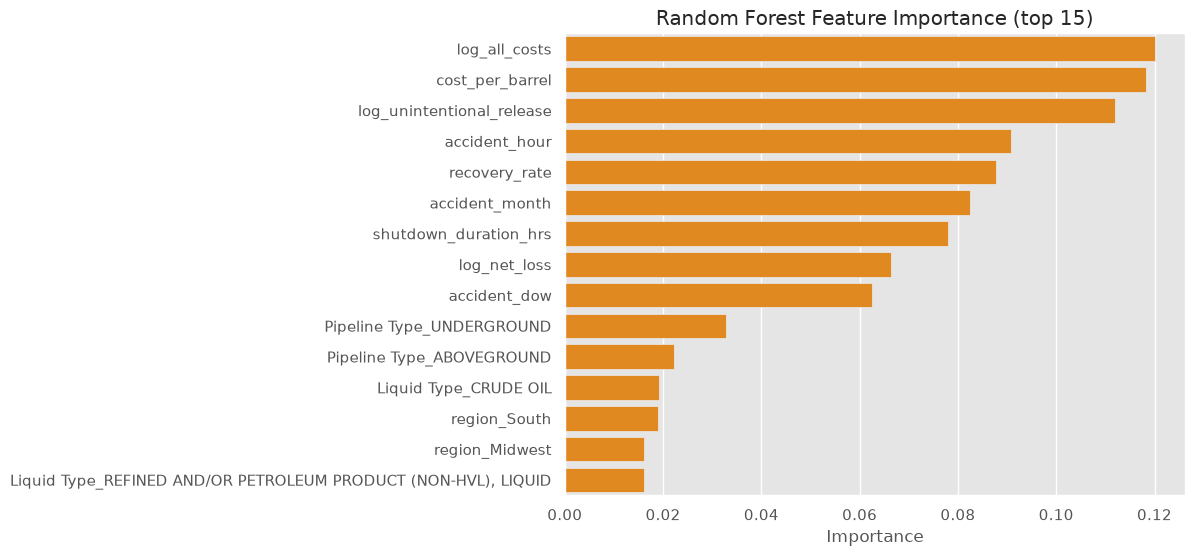

In [17]:
plt.figure(figsize = (8, 6))
top_features = importances.head(15)
sns.barplot(x = top_features.values, y = top_features.index, color = 'darkorange')
plt.title('Random Forest Feature Importance (top 15)')
plt.xlabel('Importance')
plt.ylabel('')
plt.show()

All three methods (mutual information, chi-square, RF importance) roughly agree
on the top features: the cost/volume/recovery numbers and pipeline type carry
most of the signal, while `accident_dow`, `has_evacuation` and `had_shutdown`-type
flags add very little for this particular target. Going with the numeric
features plus `Pipeline Type` and `region` as the final set - dropping
`Liquid Type` since `Pipeline Type` already captures most of the same signal
(pipe material/environment is closely tied to what it's allowed to carry) and
it adds a lot of extra dummy columns for not much extra importance.

In [18]:
final_numeric = numeric_features
final_categorical = ['Pipeline Type', 'region']

model_df = pipe[final_numeric + final_categorical + ['Cause Category']].copy()
model_df.to_csv('pipeline_accidents_features.csv', index = False)
model_df.shape

(2795, 15)

Saving this as `pipeline_accidents_features.csv` so the modeling and clustering notebooks can both start from the same feature set instead of redoing this whole process.